In [1]:
import torch
import torch.nn as nn
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False


In [2]:

class SmallCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        self.features = nn.Sequential(
            # S -> S/2 -> S/4
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=7,
                stride=2,
                padding=3,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1,
            ),

            # S/4 -> S/4
            nn.Conv2d(
                32, 64,
                kernel_size=5,
                stride=1,
                padding=2,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # S/4 -> S/8
            nn.Conv2d(
                64, 128,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # S/8 -> S/8
            nn.Conv2d(
                128, 256,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False,
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # S/8 -> S/16
            nn.Conv2d(
                256, 256,
                kernel_size=3,
                stride=2,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # S/16 -> S/16
            nn.Conv2d(
                256, 512,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False,
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x



In [3]:
DEVICE = 'cuda'

In [4]:
model = SmallCNN(100)
model = model.to(DEVICE)
model = model.eval()

# 4. Measurement grid

In [5]:
IMAGE_SIZES = (32, 64, 128, 160, 192, 224, 256, 272, 384, 480, 512)
BATCH_SIZES = (1, 2, 4, 8, 16, 32, 64, 102, 128, 178, 244, 256)
# Extras sampled with NumPy seed 20260924 from the upper allowed ranges.


```python
# 256, 800 - Out of memory

for batch_size in BATCH_SIZES:
    for image_size in IMAGE_SIZES:
        try:
            input = torch.randn(batch_size, 3, image_size, image_size).to(DEVICE)

            with torch.inference_mode():
                y = model(input)
        except:
            print(batch_size, image_size)
```


# 5. Part 1 - Derivations on paper (handwritten)

## FLOPS

0. Обозначения
S — сторона исходного изображения (квадратного)

B — количество в батче

D_input, D_output — количество входных и выходных каналов конкретного слоя

K — размер ядра

P — паддинг

T — stride

H_input, H_output — пространственный размер входа и выхода конкретного слоя

---

1. Формула одной свертки

H_output = (H_input - K + 2P) / T + 1

FLOPs_conv = B * 2 * D_input * K^2 * D_output * H_output^2

----

2. FLOPs блока Conv + BatchNorm + ReLU =

B * D_output * H_output^2 * (2 * D_input * K^2 + 5)

Для пуилинга:

FLOPs_pool = B * D_input * H_output^2 * (K^2 - 1)


3. Параметры сети

H2  = ceil(S / 2)

H4  = ceil(S / 4)

H8  = ceil(S / 8)

H16 = ceil(S / 16)

---
значения получил через в формулы выше:

Conv1 + BN + ReLU: B * 9568 * H2^2

MaxPool:          B * 256 * H4^2

Conv2 + BN + ReLU: B * 102720 * H4^2

Conv3 + BN + ReLU: B * 148096 * H8^2

Conv4 + BN + ReLU: B * 66816 * H8^2

Conv5 + BN + ReLU: B * 1180928 * H16^2

Conv6 + BN + ReLU: B * 264704 * H16^2

---
Классификатор:

AdaptiveAvgPool:  B * 512 * H16^2

Flatten:         0

Linear 512→256:   B * (2 * 512 * 256 + 256)

ReLU:            B * 256

Linear 256→100:   B * (2 * 256 * 100 + 100)

4. Итоговая формула

FLOPs(S, B) = B * (
    9568 * ceil(S / 2)^2
    + 102976 * ceil(S / 4)^2
    + 214912 * ceil(S / 8)^2
    + 1446144 * ceil(S / 16)^2
    + 313956
)

Для данной сети:

FLOPs(S, B) = B * (17835 * S^2 + 313956)

### Как я к этому пришел

```python
# --------------------------------------------- ПОДСЧЕТ FLOPS ---------------------------------------------
# ---- РАЗБОР ДЛЯ ПЕРВОГО БЛОКА (слоя?) СВЕРТКИ
# 1.ПРИМЕР img_size (8, 8)

# для примера возьмем img_size (8, 8) kernel_size 7 пока без паддингов и т д
# операций flops будет:
# 1) для 1 пикселя 3 скалярных произведения (3 канала) + сложения (или наложения) 3 числа в одно - 3 операции сложения => 3 + 3 =6 flops
# 2) всего таких операций на одной свертке- 7^2. В итоге - 7^2 * 6 = 294 FLOPS для одной свертки 7 на 7
# 3) всего сверток 4 (на 8, 8) -> 294 * 4 = 1176
# 4) всего каналов 32 -> 1176 * 32 = 37362
# немало!

# 2. ВЫВЕДЕМ ФОРМУЛУ
# FLOPS 1 слоя свертки 1 кариинки = 6 * 7^2  * (s -7 + 1) ^ 2 * 32

# 3. ДОБАВИМ PADDING, STRIDE, BATCH
# p - padding
# s - stride
# b - batch_size
# FLOPS 1 слоя свертки = B * 6 * 7^2  * floor(((s - 7 + 2P) / T) + 1) ^ 2 * 32

# ----- ОБЩАЯ ФОРМУЛА ДЛЯ БЛОКОВ СВЕРТКИ
# B * 2 D_input * K ^2 * (((S - K + 2P) / T) + 1) ^ 2 * D_output
# где:
# B - batch_size
# D_input - размерность входного изображения (первый слой - 3)
# K - kernel_size
# S - image_size (квадратное )
# P - padding
# T - stide
# D_output - количество каналов на выход


# ------- ДОБАВИМ batchnorm, relu, maxpoo;

# 1. batchnorm (считаем как eval)
# статистика батча не считаем, так как мы на инференсе
# для каждого значения batchnorm делает:
#   - вычитаем из среднего
#   - делим на стандартное отклонение
#   - домножаем на множитель
#   - добавляем сдвиг
# ИТОГО - всего 4 flops

# 4 * B * D_input * S^2


# 2. relu
# Relu обрабатывает каждый элемент 1 раз
# B * S^2 * D_input (кол-ко каналов входных в слой)

# maxpooling
# в целом выше уже все описал
# B * D_input (кол-во каналов входных в слой ) * D_output (на выход) ^ 2 * (Kp^2 - 1),
# где
# Kp - размер окна пулинга

-----
# и добавим в конце классификатор:
# ну там уже понятно по аналогии
```


## Memory

ПАМЯТЬ МОДЕЛИ

свертки:              883 296 чисел

BatchNorm:              4 992 числа

линейные слои:        157 028 числа

BatchNorm:      6 × 8 байт

итого = 4 × (883 296 + 4 992 + 157 028) + 6 × 8
        = 4 181 312 байт


ПИК ПАМЯТИ ДАННЫХ

Исходный батч:     3BS ^ 2 чисел

вызод Conv1:       8BS ^ 2 чисел

выход BatchNorm1:  8BS ^ 2 чисел


M_data(S, B) = 4 × (3BS^2 + 8BS^2 + 8BS^2)
             = 76BS² байт


ИТОГ

Memory(S, B) ≈ 4 181 312 + 76BS ^ 2 байт


Обозначения:
S — сторона входного изображения, кратная 16;
B — размер батча;
FP32 — 4 байта на одно число.

Допущение: входной батч остаётся на GPU во время прохода.
Временная память GPU-операций в оценку не включена.

### Как я к этому пришел

In [6]:
# веса - fp32

# ------- ВЕСА МОДЕЛИ
# ------ веса 1 блока
# сверток - D_input * K * K * D_output
# для 1 блока - 3 * 7 * 7 * 32 = 4704 параметра
# релу, память не тратит
# пулинг - посчитем на этапе весов данных
# батчнорм - gemma и beta обучается, среднее и дисперсия накапливаются. Итого на 1 канал - 4 веса, на все - 4 * D_otput = 4 * 32 = 128 параметров
# итого для 1 блока - 4704 + 128 = 4832 параметров

# ОСТАЛЬНЫЕ БЛОКИ
# по аналогии как выше посчитаем все веса сверток также и голову классификационную


# ИТОГ
# получилось - 1 042 820 весов + 2496 для батч норма накопленных статистик. Вес 4 байта -> 4 181 312 байт

# ------- ВЕСА  ДАННЫХ (на входе и в процессе)
# 1 слой для примера
# вход
# картинки - B * D_input * S * S -> 3 * 7 * 7 = 147 чисел на входе

# выход
# B * D_output * (floor((S + 2P − K) / T) + 1)^2
# , где
# S - image_size
# P - паддинг
# K - kernel_size
# T - strude
# D_output - каналов на выходе

# еще слой  пулинга

# по аналогии посчитаем вес всех слоев
# вход 3BS^2
# Conv1 -> BN1 -> relu 32B(S/2)^ 2 = 8BS ^ 2
# MaxPool 32B(S/4)^2 = 2BS^2
# Conv2 -> BN2 -> ReLU	64B(S/4)^2 = 4BS^2
# Conv3 -> BN3 -> ReLU	128B(S/8)^2 = 2BS^2
# ну и дальше явно будет меньше!

# ИТОГ
# пиковый веc данных - ()3 * B * S ^ 2) + (8 * B * S^2 ) + (8 * B * S ^ 2)) * 4 байт, где B - батч сайз, S - размер стороны картинки
# 1 слагаемое - исходный батч
# 2 слагаемое - conv1
# 3 слагаемое - после батч норма

# -------------------
# ИТОГОВЫЙ ПИКОВЫЙ ВЕС
# Memory(S, B) ≈ 4 181 312 + 4 × (3 + 8 + 8)BS² = 4 181 312 + 76BS² байт.

## Bytes moved (needed for latency and energy).


```text
BYTES MOVED — ЧТЕНИЯ И ЗАПИСИ ЗА один форвард

# считаем что веса модели тоже подгружаем
# из предыдущих блоков берем слагаемые


ПРИЗНАКИ

Слой        Прочитано + записано, чисел FP32

Conv1       3BS^ 2 + 4 704 + 8BS^ 2

BN1         8BS^ 2 + 128 + 8BS^ 2

ReLU1       8BS^ 2 + 8BS^ 2

MaxPool     8BS^ 2 + 2BS^ 2


Conv2       2BS^ 2 + 51 200 + 4BS^ 2

BN2         4BS^ 2 + 256 + 4BS^ 2

ReLU2       4BS^ 2 + 4BS^ 2


Conv3       4BS^ 2 + 73 728 + 2BS^ 2

BN3         2BS^ 2 + 512 + 2BS^ 2

ReLU3       2BS^ 2 + 2BS^ 2


Conv4       2BS^ 2 + 32 768 + 4BS^ 2

BN4         4BS^ 2 + 1 024 + 4BS^ 2

ReLU4       4BS^ 2 + 4BS^ 2


Conv5       4BS^ 2 + 589 824 + BS^ 2

BN5         BS^ 2 + 1 024 + BS^ 2

ReLU5       BS^ 2 + BS^ 2


Conv6       BS^ 2 + 131 072 + 2BS^ 2

BN6         2BS^ 2 + 2 048 + 2BS^ 2

ReLU6       2BS^ 2 + 2BS^ 2


Итого для признаковой части:
131BS^ 2 + 883 296 + 4 992 чисел FP32


КЛАССИФИКАТОР

AdaptiveAvgPool:  прочитать 2BS^ 2, записать 512B

Flatten:          0 — представление тех же данных

Linear 512→256:   прочитать 512B + 131 328 весов и bias,
                  записать 256B

ReLU(inplace):    прочитать 256B, записать 256B

Linear 256→100:   прочитать 256B + 25 700 весов и bias,
                  записать 100B


Итого для классификатора:
2BS^ 2 + 2 148B + 157 028 чисел FP32


ИТОГ

BytesMoved(S, B)
≈ 4 × (133BS^ 2 + 2 148B + 1 045 316)
= 532BS^ 2 + 8 592B + 4 181 264 байт


Обозначения:
S — сторона входного изображения, кратная 16;
B — размер батча.

```

## Latency

из того что выше:

F(S, B) = B × (17 835S^2 + 313 956)                  
FLOPs

Q(S, B) = 532BS^2 + 8 592B + 4 181 264               
байт

LATENCY

Latency(S, B; θ_L) =
    τ + max(

        B × (17 835S^2 + 313 956) / C, # flops
        (532BS^2 + 8 592B + 4 181 264) / W # память

    )

θ_L = (τ, C, W)

τ — постоянные затраты на запуск одного форварда в секундах

C — эффективная скорость вычислений, flops/с

W — эффективная пропускная способность памяти, байт/с

## Energy

ENERGY

Energy(S, B; θ_E) =

    P × Latency(S, B; θ_L)

    + ε_F × B × (17 835S^2 + 313 956)

    + ε_M × (532BS^2 + 8 592B + 4 181 264)

θ_E = (τ, C, W, P, ε_F, ε_M)

P — базовая мощность всего gpy, ватт

ε_F — дополнительная энергия на один flops, дж / flops

ε_M — дополнительная энергия на один переданный байт, дж / байт

### Подбор численных констант на Tesla T4

Численные константы в **моих формулах выше** подобраны по 105 конфигурациям. Ещё 27 конфигураций оставлены для независимой проверки ошибки:

```text
τ = 0.000554166924403 s
C = 2.40511333111e+12 FLOPs/s
W = 79383345243.3 bytes/s
P = 52.3244324991 W
ε_F = 5.01899097704e-12 J/FLOP
ε_M = 3.45306909748e-31 J/byte ≈ 0
```

```text
Latency(S,B) = 0.000554166924403
  + max( B(17835 S² + 313956) / 2.40511333111e+12,
         (532 B S² + 8592 B + 4181264) / 79383345243.3 )  seconds

Energy(S,B) = 52.3244324991 × Latency(S,B)
  + 5.01899097704e-12 × B(17835 S² + 313956)
  + 3.45306909748e-31 × (532 B S² + 8592 B + 4181264)  joules
```

`P`, `ε_F` и `ε_M` получены совместной подгонкой, поэтому `P` здесь эффективный коэффициент, а не независимо измеренная мощность простоя. Корреляция FLOPs и оценённых байтов на calibration-точках — 0.99999999997; почти нулевое `ε_M` не доказывает отсутствия энергозатрат памяти.


# 6. Part 2 — Code


## Реализация аналитических функций
Функции ниже повторяют коэффициенты из моих выкладок. Размеры `S` в эксперименте кратны 16. `theta` будет заполнена после подбора констант по измерениям GPU.


In [7]:
"""Analytical equations transcribed from the supplied notebook.

S must be a multiple of 16 for the simplified closed forms used here.
Units: FLOPs, bytes, seconds, and joules respectively.
"""
import numpy as np


def _inputs(image_size, batch):
    s = np.asarray(image_size, dtype=float)
    b = np.asarray(batch, dtype=float)
    if np.any(s <= 0) or np.any(b <= 0):
        raise ValueError('image_size and batch must be positive')
    return s, b


def _scalar_or_array(value):
    return float(value) if np.ndim(value) == 0 else value


def flops(image_size, batch):
    s, b = _inputs(image_size, batch)
    return _scalar_or_array(b * (17835 * s**2 + 313956))


def memory(image_size, batch):
    s, b = _inputs(image_size, batch)
    return _scalar_or_array(4181312 + 76 * b * s**2)


def bytes_moved(image_size, batch):
    s, b = _inputs(image_size, batch)
    return _scalar_or_array(532 * b * s**2 + 8592 * b + 4181264)


def latency(image_size, batch, theta):
    tau, compute_rate, bandwidth = (float(theta[k]) for k in ('tau', 'compute_rate', 'bandwidth'))
    if tau < 0 or compute_rate <= 0 or bandwidth <= 0:
        raise ValueError('latency parameters must be physically valid')
    return _scalar_or_array(tau + np.maximum(flops(image_size, batch) / compute_rate,
                                               bytes_moved(image_size, batch) / bandwidth))


def energy(image_size, batch, theta_energy):
    p, eps_f, eps_m = (float(theta_energy[k]) for k in ('power', 'energy_per_flop', 'energy_per_byte'))
    if min(p, eps_f, eps_m) < 0:
        raise ValueError('energy parameters must be nonnegative')
    return _scalar_or_array(p * latency(image_size, batch, theta_energy)
                            + eps_f * flops(image_size, batch)
                            + eps_m * bytes_moved(image_size, batch))


In [8]:
import numpy as np
ss, bb = np.meshgrid(IMAGE_SIZES, BATCH_SIZES, indexing="ij")
assert flops(ss, bb).shape == (11, 12)
assert memory(ss, bb).shape == (11, 12)
print("FLOPs and memory broadcasting: OK")


FLOPs and memory broadcasting: OK


## GPU измерения, подбор констант и графики

Основная последовательность эксперимента здесь, рядом с моделью, формулами и моими комментариями. Скрипты `measure.py`, `profile_kernels.py`, `calibrate.py` и `plots.py` содержат вспомогательные детали измерения, профилирования, подгонки и отрисовки. Для повторения положите их вместе с `models.py` и `equations.py` рядом с ноутбуком и выполните ячейки по порядку в GPU runtime.

Сетка — 132 конфигурации. Для каждой точки делается 10 прогревочных проходов, затем 7 синхронизированных замеров latency; энергия оценивается по серии проходов с NVML. Измерения записываются в CSV по мере выполнения и могут продолжаться после остановки. Константы подбираются по 105 точкам, а 27 отложенных точек используются для проверки. На графиках показаны только отложенные измерения.


In [9]:
from pathlib import Path
from measure import SIZES, BATCHES, WARMUP_REPEATS, main as measure_grid
from profile_kernels import main as profile_kernels

assert torch.cuda.is_available(), "Выберите GPU runtime (Colab или Kaggle)"
assert tuple(SIZES) == IMAGE_SIZES and tuple(BATCHES) == BATCH_SIZES
assert WARMUP_REPEATS == 10
measure_grid()
if not Path("results/kernels.csv").exists():
    profile_kernels()


GPU: Tesla T4 power sensor: True


In [10]:
from calibrate import main as fit_parameters
from plots import main as draw_plots
import json

fit_parameters()
draw_plots()
theta = json.loads(Path("results/theta.json").read_text())["theta"]
print("Latency: tau = {tau:.6g} s, C = {compute_rate:.6g} FLOPs/s, W = {bandwidth:.6g} bytes/s".format(**theta))
if theta["power"] is not None:
    print("Energy: P = {power:.6g} W, eps_F = {energy_per_flop:.6g} J/FLOP, eps_M = {energy_per_byte:.6g} J/byte".format(**theta))
else:
    print("Energy sensor unavailable; energy constants could not be fitted")


{
  "theta": {
    "tau": 0.0005541396224441168,
    "compute_rate": 2405168852190.8423,
    "bandwidth": 79385171988.9299,
    "power": 52.32695906143736,
    "energy_per_flop": 5.018445353482328e-12,
    "energy_per_byte": 3.452723942109067e-31
  },
  "train_count": 105,
  "validation_count": 27,
  "oom_count": 0,
  "latency_fit_converged": true,
  "latency_train": {
    "n": 105,
    "mape_pct": 24.586291912531237,
    "median_ape_pct": 22.11617569387055,
    "rmse": 0.024027998988933073
  },
  "memory_train": {
    "n": 105,
    "mape_pct": 33.24277193141779,
    "median_ape_pct": 26.82707896047892,
    "rmse": 270128478.21120465
  },
  "flops_bytes_correlation": 0.9999999999669462,
  "energy_design_condition_number": 1756.9303257014872,
  "power_unique_values_min": 15,
  "energy_duration_min_s": 2.6453493270000195,
  "latency_validation": {
    "n": 27,
    "mape_pct": 23.75385201527328,
    "median_ape_pct": 19.446666775769916,
    "rmse": 0.023219840959657415
  },
  "memory_vali

Latency: tau = 0.00055414 s, C = 2.40517e+12 FLOPs/s, W = 7.93852e+10 bytes/s
Energy: P = 52.327 W, eps_F = 5.01845e-12 J/FLOP, eps_M = 3.45272e-31 J/byte


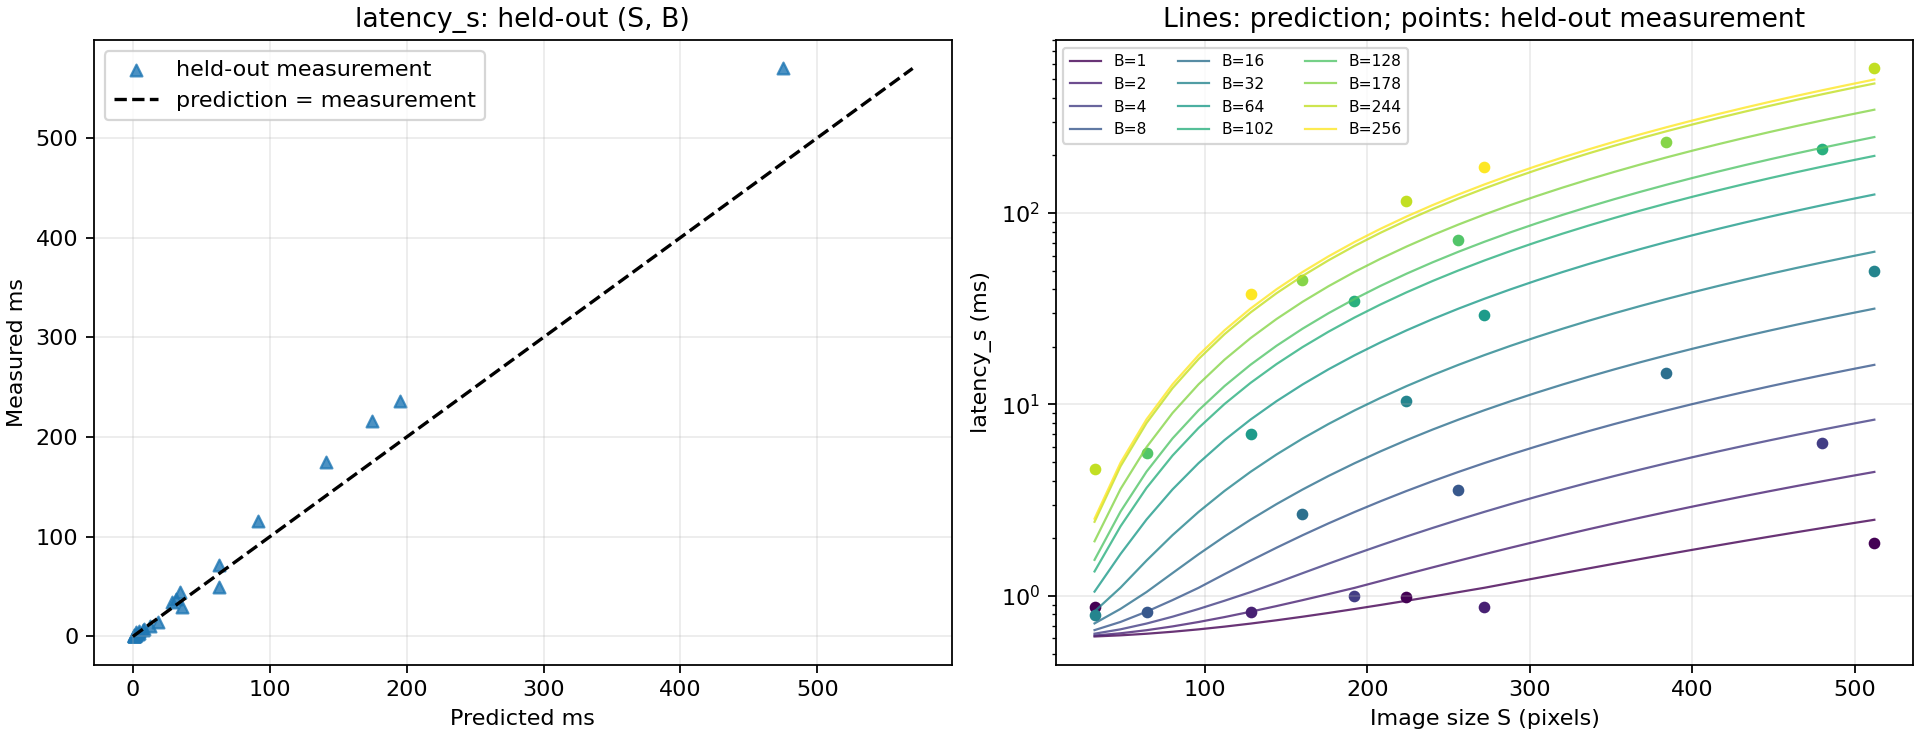

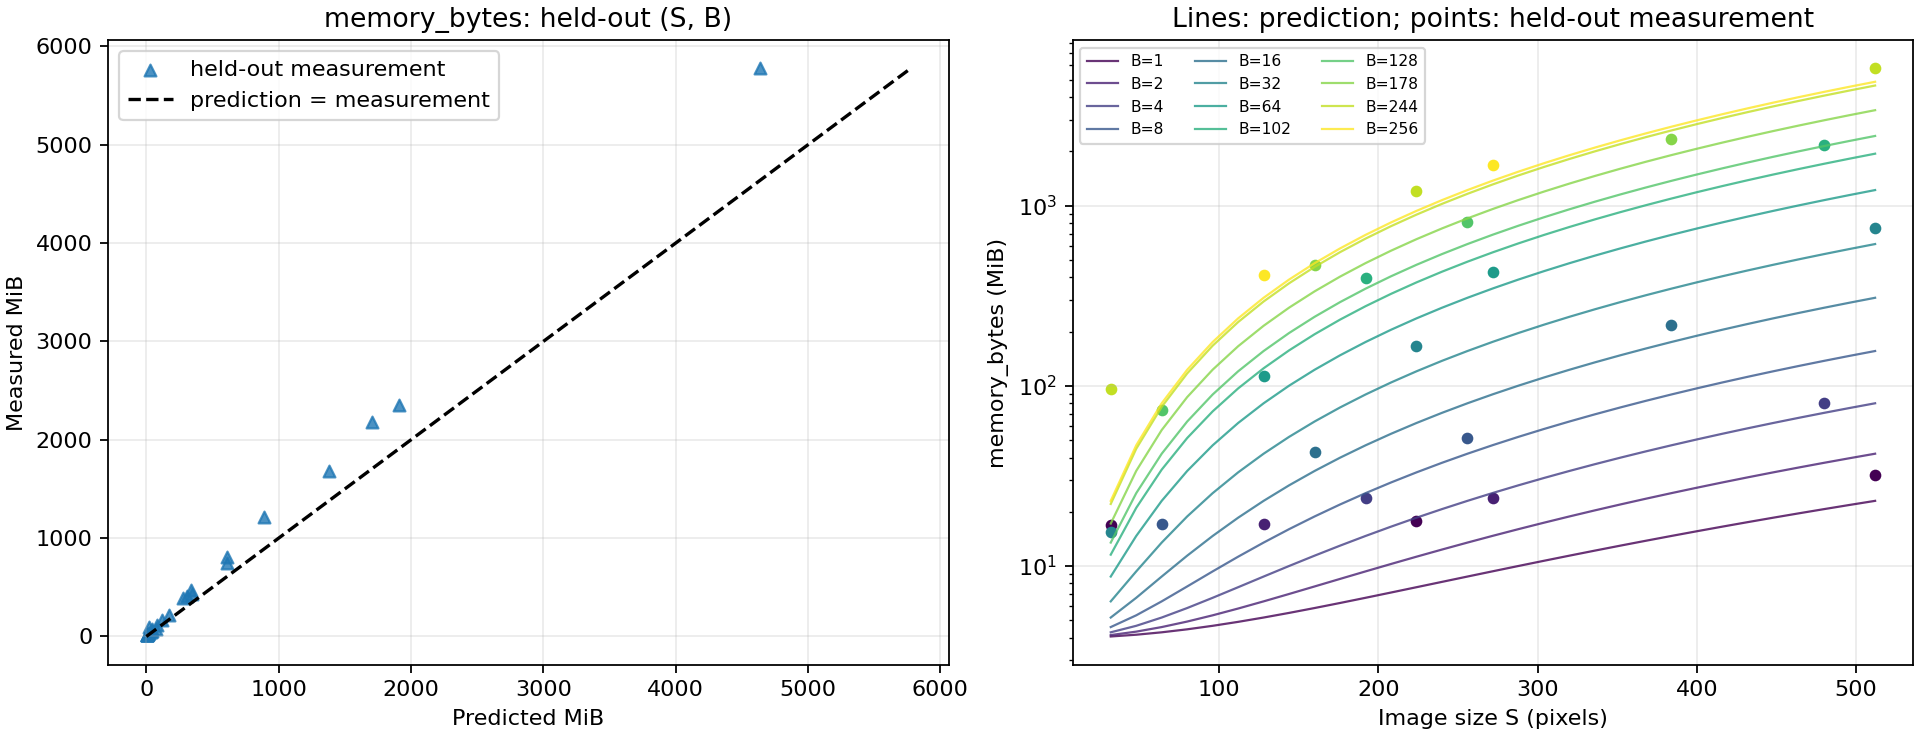

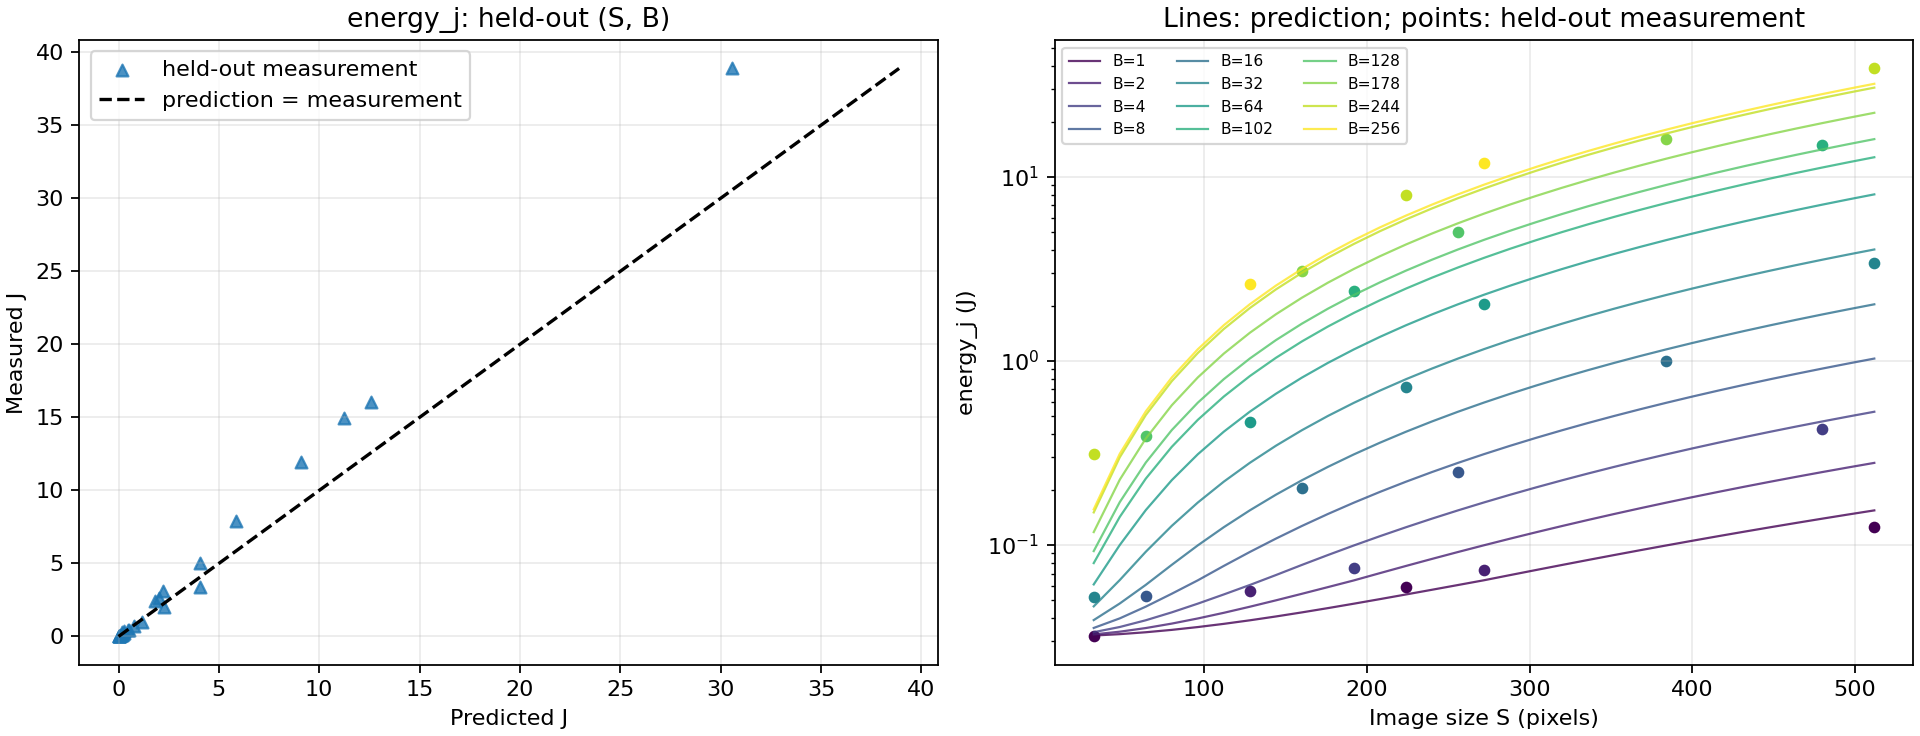

In [11]:
from IPython.display import display, Image
for name in ["latency", "memory", "energy"]:
    image_path = Path("results/figures") / (name + ".png")
    if image_path.exists():
        display(Image(filename=str(image_path)))


# Итог


| Величина | MAPE на отложенных точках |
|---|---:|
| Latency | 23.75% |
| Memory | 34.07% |
| Energy | 20.00% |

Наибольший измеренный пик памяти — **5.75 GiB** против **4.75 GiB** по формуле.
